<a href="https://colab.research.google.com/github/joaomerjam/ECON3916-33674-Statistical-Machine-Learning/blob/main/Lab%2016/lab16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install wbgapi

In [8]:
# ============================================================
# SETUP — Run this cell first
# ============================================================

# Uncomment and run once if packages are missing:
# !pip install wbgapi scikit-learn matplotlib seaborn numpy pandas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import wbgapi as wb

# Reproducibility
np.random.seed(42)

print("Setup complete ✓")

Setup complete ✓


In [12]:
# ============================================================
# PART 1A: Download World Bank Data
# ============================================================

INDICATORS = {
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries, 2013–2019...")

frames = []
for code, name in INDICATORS.items():
    try:
        df = wb.data.DataFrame(code, time=range(2013, 2020), skipBlanks=False, labels=False)
        # df is indexed by economy, columns are years — take the mean across years
        s = df.mean(axis=1)
        s.name = name
        frames.append(s)
    except Exception as e:
        print(f"  Skipping {name} ({code}): {e}")

raw_data = pd.concat(frames, axis=1)
raw_data.index.name = 'country'

print(f"Raw data shape: {raw_data.shape}")  # should be (~200 countries) × (36 indicators)
print("Download successful ✓")

  Skipping paved_roads_pct (IS.ROD.PAVE.ZS): APIError: JSON decoding error (https://api.worldbank.org/v2/en/sources/2/series/IS.ROD.PAVE.ZS/country/all/time/YR2013;YR2014;YR2015;YR2016;YR2017;YR2018;YR2019?per_page=1000&page=1&format=json)
  Skipping co2_emissions_per_capita (EN.ATM.CO2E.PC): APIError: JSON decoding error (https://api.worldbank.org/v2/en/sources/2/series/EN.ATM.CO2E.PC/country/all/time/YR2013;YR2014;YR2015;YR2016;YR2017;YR2018;YR2019?per_page=1000&page=1&format=json)
Raw data shape: (266, 35)
Download successful ✓


In [13]:
# ============================================================
# PART 1B: Build the Analysis Dataset
# ============================================================
# Average all indicators across the 2013-2019 period per country
# This gives us one observation per country — a cross-sectional dataset

# Average over time dimension
if isinstance(raw_data.index, pd.MultiIndex):
    country_data = raw_data.groupby(level=0).mean()
else:
    country_data = raw_data.copy()

# Drop countries with too many missing values (keep countries with >= 60% non-missing)
threshold = 0.60
country_data = country_data.dropna(thresh=int(threshold * country_data.shape[1]))

# Drop indicators with too many missing values across countries
country_data = country_data.dropna(axis=1, thresh=int(threshold * len(country_data)))

# Final fill: impute remaining missing values with the cross-country median
# (Standard practice in cross-country empirics — removes selection bias from listwise deletion)
country_data = country_data.fillna(country_data.median())

print(f"Final dataset: {len(country_data)} countries × {country_data.shape[1]} indicators")
print(f"\nSample countries: {list(country_data.index[:5])}")
print(f"\nIndicators retained: {list(country_data.columns)}")
print(f"\nGDP growth summary:")
print(country_data[OUTCOME_VAR].describe().round(2))

Final dataset: 238 countries × 29 indicators

Sample countries: ['ABW', 'AFE', 'AFG', 'AFW', 'AGO']

Indicators retained: ['gdp_growth_pc', 'trade_pct_gdp', 'fdi_inflows_pct_gdp', 'tariff_rate_avg', 'royalties_receipts', 'inflation_cpi', 'govt_expenditure_pct_gdp', 'current_account_pct_gdp', 'real_interest_rate', 'exchange_rate_official', 'secondary_enrollment_gross', 'tertiary_enrollment_gross', 'adult_literacy_rate', 'education_expenditure_pct_gdp', 'unemployment_rate', 'internet_users_pct', 'mobile_subscriptions_per100', 'electricity_access_pct', 'life_expectancy', 'infant_mortality_per1000', 'population_growth', 'urbanization_pct', 'health_expenditure_pct_gdp', 'atms_per100k', 'private_credit_pct_gdp', 'natural_resource_rents_pct_gdp', 'renewable_energy_pct', 'agriculture_pct_gdp', 'arable_land_pct']

GDP growth summary:
count    238.00
mean       1.76
std        2.45
min      -12.55
25%        0.57
50%        1.80
75%        3.30
max        7.39
Name: gdp_growth_pc, dtype: float64

In [14]:
# ============================================================
# PART 1C: Train-Test Split & OLS Baseline
# ============================================================
# We split countries (not time periods) into train/test sets.
# This tests whether our model generalizes across countries —
# the realistic use case for an IMF forecaster.

# Separate outcome (y) from predictors (X)
feature_cols = [c for c in country_data.columns if c != OUTCOME_VAR]

X = country_data[feature_cols].values
y = country_data[OUTCOME_VAR].values
feature_names = feature_cols

# 70/30 train-test split (stratified not needed for regression)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f"Training countries: {X_train.shape[0]}")
print(f"Test countries: {X_test.shape[0]}")
print(f"Number of predictors: {X_train.shape[1]}")
print(f"Predictor-to-observation ratio (train): p/n = {X_train.shape[1]}/{X_train.shape[0]} = {X_train.shape[1]/X_train.shape[0]:.2f}")
print()
print("If p/n > 0.5, OLS is at serious risk of overfitting.")

# Standardize features (critical for Ridge and Lasso — do it manually here to inspect later)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only!
X_test_scaled  = scaler.transform(X_test)         # apply same transform to test

print("\nFeatures standardized (zero mean, unit variance) ✓")

Training countries: 166
Test countries: 72
Number of predictors: 28
Predictor-to-observation ratio (train): p/n = 28/166 = 0.17

If p/n > 0.5, OLS is at serious risk of overfitting.

Features standardized (zero mean, unit variance) ✓


In [15]:
# ============================================================
# PART 1D: OLS Baseline — Demonstrating the Failure Mode
# ============================================================
# OLS will overfit when p/n is large. We predict this BEFORE looking at results.
# Prediction: high training R², but much lower (possibly negative) test R².

ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

# Training performance
y_train_pred_ols = ols_model.predict(X_train_scaled)
ols_train_r2  = r2_score(y_train, y_train_pred_ols)
ols_train_mse = mean_squared_error(y_train, y_train_pred_ols)

# Test performance
y_test_pred_ols = ols_model.predict(X_test_scaled)
ols_test_r2  = r2_score(y_test, y_test_pred_ols)
ols_test_mse = mean_squared_error(y_test, y_test_pred_ols)

print("=" * 45)
print("OLS BASELINE RESULTS")
print("=" * 45)
print(f"Training R²:  {ols_train_r2:.3f}")
print(f"Test R²:      {ols_test_r2:.3f}")
print(f"")
print(f"Training MSE: {ols_train_mse:.3f}")
print(f"Test MSE:     {ols_test_mse:.3f}")
print(f"")
print(f"Gap (Train R² - Test R²): {ols_train_r2 - ols_test_r2:.3f}")
print("=" * 45)
print()
print("Interpretation:")
print(f"  OLS fits the training data {ols_train_r2:.0%} — but only explains")
print(f"  {max(ols_test_r2, 0):.0%} of test variance. This is overfitting.")

OLS BASELINE RESULTS
Training R²:  0.600
Test R²:      -0.849

Training MSE: 2.640
Test MSE:     8.252

Gap (Train R² - Test R²): 1.449

Interpretation:
  OLS fits the training data 60% — but only explains
  0% of test variance. This is overfitting.


In [16]:
# ============================================================
# PART 2A: Ridge Regression with Cross-Validated Lambda
# ============================================================
# YOUR TASK: Complete the RidgeCV fit below.
# RidgeCV tries all alphas in the list and picks the one with
# lowest cross-validation error.
#
# Note: sklearn calls λ "alpha" for historical reasons.

# Grid of lambda (alpha) values to try — log-spaced from 0.01 to 1000
lambda_grid = np.logspace(-2, 3, 50)

# TODO: Create a RidgeCV with 5-fold CV and the lambda_grid above
# Hint: RidgeCV(alphas=..., cv=5)
ridge_cv = RidgeCV(alphas=lambda_grid, cv=5)  #

# TODO: Fit ridge_cv on the scaled training data
ridge_cv.fit(X_train_scaled, y_train)
# Evaluate on test set
y_test_pred_ridge = ridge_cv.predict(X_test_scaled)
ridge_test_r2  = r2_score(y_test, y_test_pred_ridge)
ridge_test_mse = mean_squared_error(y_test, y_test_pred_ridge)

print("=" * 45)
print("RIDGE REGRESSION RESULTS")
print("=" * 45)
print(f"Optimal λ* (CV-selected): {ridge_cv.alpha_:.4f}")
print(f"Non-zero coefficients:    {np.sum(ridge_cv.coef_ != 0)} of {X_train.shape[1]}")
print(f"Test R²:                  {ridge_test_r2:.3f}")
print(f"Test MSE:                 {ridge_test_mse:.3f}")
print()
print(f"vs. OLS: Test R² = {ols_test_r2:.3f}, Test MSE = {ols_test_mse:.3f}")

RIDGE REGRESSION RESULTS
Optimal λ* (CV-selected): 47.1487
Non-zero coefficients:    28 of 28
Test R²:                  -0.051
Test MSE:                 4.691

vs. OLS: Test R² = -0.849, Test MSE = 8.252


In [17]:
# ============================================================
# PART 2B: LassoCV — Automated Feature Selection
# ============================================================

def fit_lasso_cv(X_train, y_train, X_test, y_test, cv=5):
    """
    Fit LassoCV to select optimal regularization parameter and evaluate on test set.

    Parameters
    ----------
    X_train : np.ndarray, shape (n_train, p)
        Standardized training features
    y_train : np.ndarray, shape (n_train,)
        Training outcome (GDP growth)
    X_test : np.ndarray, shape (n_test, p)
        Standardized test features (same scaler as train)
    y_test : np.ndarray, shape (n_test,)
        Test outcome
    cv : int
        Number of cross-validation folds

    Returns
    -------
    lasso_model : LassoCV
        Fitted LassoCV model with optimal alpha stored in .alpha_
    test_r2 : float
        R² on held-out test set
    test_mse : float
        Mean squared error on held-out test set
    """
    # TODO: Create a LassoCV with cv folds and max_iter=10_000
    # (max_iter needs to be high for coordinate descent to converge)
    lasso_model = LassoCV(cv=cv, max_iter=10_000, random_state=42)

    # TODO: Fit the model on training data
    lasso_model.fit(X_train, y_train)

    # Predict on test set
    y_pred = lasso_model.predict(X_test)

    # TODO: Compute test R² and test MSE
    test_r2  = r2_score(y_test, y_pred)
    test_mse = mean_squared_error(y_test, y_pred)

    return lasso_model, test_r2, test_mse


# Call the function
lasso_cv_model, lasso_test_r2, lasso_test_mse = fit_lasso_cv(
    X_train_scaled, y_train, X_test_scaled, y_test, cv=5
)

n_nonzero = np.sum(lasso_cv_model.coef_ != 0)

print("=" * 45)
print("LASSO REGRESSION RESULTS")
print("=" * 45)
print(f"Optimal λ* (CV-selected): {lasso_cv_model.alpha_:.4f}")
print(f"Non-zero coefficients:    {n_nonzero} of {X_train.shape[1]}")
print(f"Test R²:                  {lasso_test_r2:.3f}")
print(f"Test MSE:                 {lasso_test_mse:.3f}")
print()
print("Selected predictors (non-zero Lasso coefficients):")
selected_features = [
    (feature_names[i], lasso_cv_model.coef_[i])
    for i in range(len(feature_names))
    if lasso_cv_model.coef_[i] != 0
]
for name, coef in sorted(selected_features, key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:<40} coef = {coef:+.4f}")

LASSO REGRESSION RESULTS
Optimal λ* (CV-selected): 0.0656
Non-zero coefficients:    17 of 28
Test R²:                  -0.330
Test MSE:                 5.934

Selected predictors (non-zero Lasso coefficients):
  inflation_cpi                            coef = -1.0241
  population_growth                        coef = -0.7707
  natural_resource_rents_pct_gdp           coef = -0.6521
  health_expenditure_pct_gdp               coef = -0.4145
  infant_mortality_per1000                 coef = -0.3856
  atms_per100k                             coef = -0.3849
  unemployment_rate                        coef = -0.3716
  renewable_energy_pct                     coef = +0.3627
  urbanization_pct                         coef = -0.3545
  exchange_rate_official                   coef = +0.3112
  arable_land_pct                          coef = +0.1881
  tertiary_enrollment_gross                coef = -0.0799
  mobile_subscriptions_per100              coef = +0.0729
  private_credit_pct_gdp            

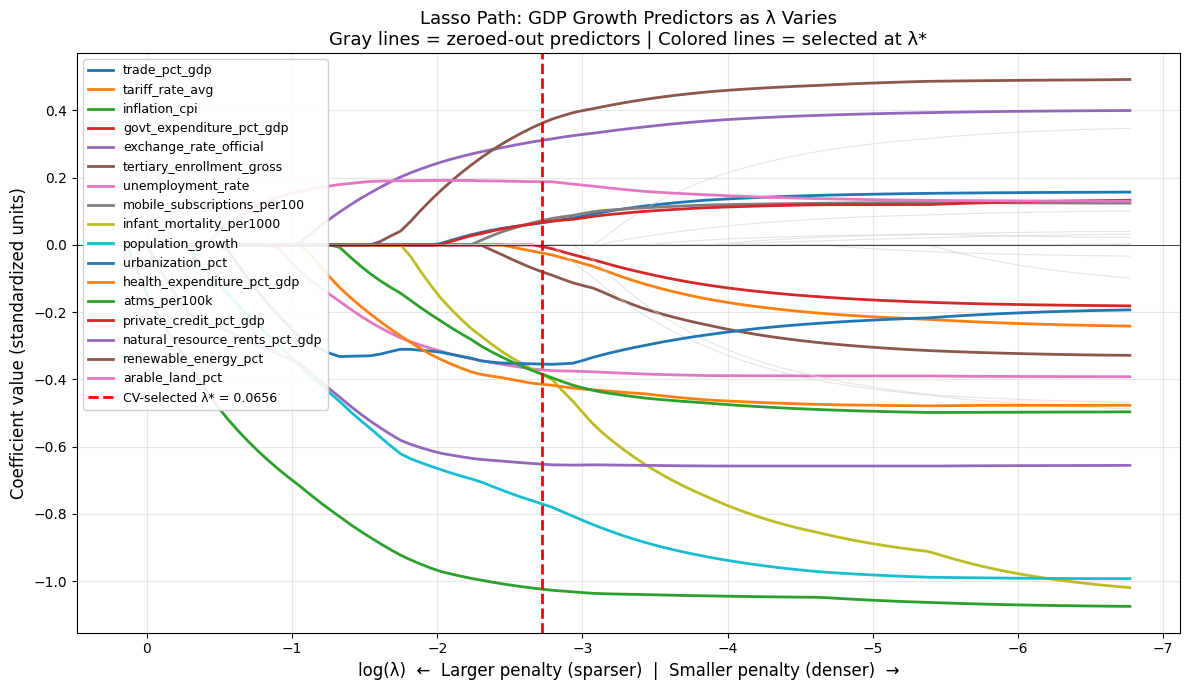

Lasso Path saved to lasso_path_gdp_growth.png


In [18]:
# ============================================================
# PART 2C: The Lasso Path — Who Enters First?
# ============================================================
# The Lasso Path traces ALL coefficient estimates as λ varies.
# - Far right (large λ): all coefficients are zero
# - Moving left (smaller λ): variables enter one by one
# - The FIRST variable to enter = the single strongest predictor
# - The vertical dashed line = our CV-selected λ*

# Compute the Lasso path using LARS algorithm (efficient — no loop needed)
# lasso_path returns: (alphas, coefs, dual_gaps)
alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled, y_train,
    eps=1e-3,       # ratio of min to max alpha in the path
    n_alphas=100,   # number of points on the path
)
# coefs_path shape: (n_features, n_alphas)

# Mark our CV-selected lambda
optimal_alpha = lasso_cv_model.alpha_

# ── PLOT ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

# Plot each predictor's coefficient path
# Only label the lines that are non-zero at optimal λ (to avoid clutter)
active_features_idx = np.where(lasso_cv_model.coef_ != 0)[0]

for i in range(len(feature_names)):
    if i in active_features_idx:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=2, label=feature_names[i])
    else:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=0.8, color='lightgray', alpha=0.6)

# Mark the CV-selected lambda
ax.axvline(np.log(optimal_alpha), color='red', linestyle='--', linewidth=2,
           label=f'CV-selected λ* = {optimal_alpha:.4f}')
ax.axhline(0, color='black', linewidth=0.5)

# Labels and formatting
ax.set_xlabel('log(λ)  ←  Larger penalty (sparser)  |  Smaller penalty (denser)  →',
               fontsize=12)
ax.set_ylabel('Coefficient value (standardized units)', fontsize=12)
ax.set_title(
    'Lasso Path: GDP Growth Predictors as λ Varies\n'
    'Gray lines = zeroed-out predictors | Colored lines = selected at λ*',
    fontsize=13
)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.invert_xaxis()  # Large lambda on left → small lambda on right (path goes left to right)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lasso_path_gdp_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Lasso Path saved to lasso_path_gdp_growth.png")

In [19]:
# ============================================================
# PART 2D: Model Comparison Table
# ============================================================
# Complete the table below — fill in the Lasso and OLS values
# using variables computed above.

comparison = pd.DataFrame({
    'Method': ['OLS', 'Ridge (RidgeCV)', 'Lasso (LassoCV)'],
    'Lambda (α*)': [
        'N/A (no penalty)',
        f'{ridge_cv.alpha_:.4f}',
        f'{lasso_cv_model.alpha_:.4f}'
    ],
    'Non-zero Predictors': [
        X_train.shape[1],                        # OLS: all predictors non-zero
        X_train.shape[1],                        # Ridge: all predictors non-zero
        np.sum(lasso_cv_model.coef_ != 0)        # Lasso: only selected predictors
    ],
    'Training R²': [
        f'{r2_score(y_train, ols_model.predict(X_train_scaled)):.3f}',
        f'{r2_score(y_train, ridge_cv.predict(X_train_scaled)):.3f}',
        f'{r2_score(y_train, lasso_cv_model.predict(X_train_scaled)):.3f}'
    ],
    'Test R²': [
        f'{ols_test_r2:.3f}',
        f'{ridge_test_r2:.3f}',
        f'{lasso_test_r2:.3f}'
    ],
    'Test MSE': [
        f'{ols_test_mse:.3f}',
        f'{ridge_test_mse:.3f}',
        f'{lasso_test_mse:.3f}'
    ]
})

print(comparison.to_string(index=False))
print()
print("Key observations:")
print(f"  • OLS training R² >> test R²: evidence of overfitting (high variance)")
print(f"  • Ridge and Lasso reduce the train-test gap")
print(f"  • Lasso selects only {np.sum(lasso_cv_model.coef_ != 0)} of {X_train.shape[1]} predictors")
print(f"  • Interpretation: the other {X_train.shape[1] - np.sum(lasso_cv_model.coef_ != 0)} are predictively redundant,")
print(f"    not necessarily economically unimportant")

         Method      Lambda (α*)  Non-zero Predictors Training R² Test R² Test MSE
            OLS N/A (no penalty)                   28       0.600  -0.849    8.252
Ridge (RidgeCV)          47.1487                   28       0.557  -0.051    4.691
Lasso (LassoCV)           0.0656                   17       0.569  -0.330    5.934

Key observations:
  • OLS training R² >> test R²: evidence of overfitting (high variance)
  • Ridge and Lasso reduce the train-test gap
  • Lasso selects only 17 of 28 predictors
  • Interpretation: the other 11 are predictively redundant,
    not necessarily economically unimportant


Question 1: A lasso zero coefficient indicates conditional predictive redundancy, not economic irrelevance. That means that paved_roacds_pct adds no additional predictive information given the other indicatrores already in the model, and itty does not show that it has no relationship with growth. Because WDI indicators share a dense correlation structure. The model says nothing about casual relationships, like if paved_raods_pct was dropped from all the regression  costs and raise productivity remains intact and unaddressed by this analysis.

Question 2: For this dataset, Lasso is the better practical choice. The high p/n ratio means we need aggressive regularization, and Lasso's automatic feature selection produces a sparser, more interpretable model — useful when briefing policymakers on which indicators matter. That said, the dense correlation structure among WDI indicators is where Ridge has a theoretical edge, since Ridge distributes shrinkage across correlated variables rather than arbitrarily zeroing all but one. In practice, if the model comparison table shows similar test R² for both, prefer Lasso for interpretability — but the selected indicators should not be treated as a definitive causal shortlist, since correlated predictors could just as easily have been chosen instead.

In [21]:
country_data.to_csv('regularization_explorer.py'.replace('.py','') + '_data.csv')
# simpler|:
country_data.to_csv('country_data.csv')

In [22]:
!streamlit run regularization_explorer.py &
import time; time.sleep(4)
from google.colab.output import eval_js
print(eval_js("google.colab.kernel.proxyPort(8501)"))

/bin/bash: line 1: streamlit: command not found
https://8501-m-s-kkb-usw1b2-2b1nku5hvgtt6-b.us-west1-2.prod.colab.dev


In [23]:
# Ai expansion
"""
============================================================
 World Bank Regularization Explorer — Streamlit Dashboard
============================================================
HOW TO RUN:
    1. Make sure your notebook variables are saved to disk first (see bottom of this file)
    2. In a Colab cell run:
           !streamlit run regularization_explorer.py &
           import time; time.sleep(3)
           from google.colab.output import eval_js
           print(eval_js("google.colab.kernel.proxyPort(8501)"))
    3. Click the printed URL to open the dashboard
============================================================
"""

import streamlit as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pickle

from sklearn.linear_model import Ridge, Lasso, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# ============================================================
# PAGE CONFIG
# ============================================================
st.set_page_config(
    page_title="WDI Regularization Explorer",
    page_icon="🌍",
    layout="wide"
)

st.title("🌍 World Bank Regularization Explorer")
st.markdown(
    "Drag the **λ slider** to watch Ridge and Lasso shrink coefficients in real time. "
    "Switch models or outcome variables and observe how the train–test R² gap responds."
)

# ============================================================
# LOAD DATA
# ============================================================
# We load the pre-processed country_data saved from the notebook.
# All heavy computation (wbgapi download, cleaning, imputation) stays
# in the notebook — Streamlit only handles the interactive layer.

@st.cache_data
def load_data():
    """Load pre-processed WDI cross-sectional dataset saved from notebook."""
    try:
        country_data = pd.read_csv("country_data.csv", index_col=0)
        return country_data
    except FileNotFoundError:
        st.error(
            "❌ `country_data.csv` not found. "
            "Run the save cell at the bottom of your notebook first:\n\n"
            "```python\ncountry_data.to_csv('country_data.csv')\n```"
        )
        st.stop()

country_data = load_data()

# ============================================================
# SIDEBAR CONTROLS
# ============================================================
st.sidebar.header("⚙️ Controls")

# Model selector
model_type = st.sidebar.radio(
    "Regularization method",
    options=["Lasso", "Ridge"],
    index=0,
    help="Lasso (L1) drives coefficients to exactly zero. Ridge (L2) shrinks all coefficients but keeps them non-zero."
)

# Outcome variable selector — any numeric column can be the target
numeric_cols = country_data.select_dtypes(include=np.number).columns.tolist()
outcome_var = st.sidebar.selectbox(
    "Outcome variable (y)",
    options=numeric_cols,
    index=numeric_cols.index("gdp_growth_pc") if "gdp_growth_pc" in numeric_cols else 0,
    help="The dependent variable. All other numeric columns become predictors."
)

# Lambda slider — log scale from 0.001 to 500
# st.slider() fires a full Streamlit re-run on every move, which triggers
# a refit of the model at the new lambda value below.
log_lambda = st.sidebar.slider(
    "log₁₀(λ)  [penalty strength]",
    min_value=-3.0,
    max_value=3.0,
    value=0.0,
    step=0.05,
    help="Move right → stronger penalty → more shrinkage. Move left → weaker penalty → approaches OLS."
)
lam = 10 ** log_lambda  # convert back to raw lambda

st.sidebar.markdown(f"**Selected λ = {lam:.4f}**")

# Train/test split seed
test_size = st.sidebar.slider("Test set fraction", 0.10, 0.40, 0.20, 0.05)
random_seed = st.sidebar.number_input("Random seed", value=42, step=1)

# ============================================================
# PREPARE FEATURES
# ============================================================
# Drop outcome and any non-numeric columns
X_df = country_data.drop(columns=[outcome_var]).select_dtypes(include=np.number)
y = country_data[outcome_var].values
feature_names = X_df.columns.tolist()

# Train/test split — divides countries (cross-sectional generalization)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_df.values, y, test_size=test_size, random_state=int(random_seed)
)

# Standardize: fit scaler on train only, apply to both
# This is critical — leaking test statistics into the scaler inflates test R²
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# ============================================================
# FIT MODEL AT SELECTED LAMBDA
# ============================================================
# Every time the slider moves, Streamlit re-runs this script from top to bottom.
# The model is refit here at the current lambda value — this is intentionally
# lightweight (a single Ridge or Lasso fit, not cross-validation).

if model_type == "Lasso":
    model = Lasso(alpha=lam, max_iter=10_000, random_state=42)
else:
    model = Ridge(alpha=lam)

model.fit(X_train_scaled, y_train)
coefs = model.coef_

y_train_pred = model.predict(X_train_scaled)
y_test_pred  = model.predict(X_test_scaled)

train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test,  y_test_pred)
n_nonzero = np.sum(coefs != 0)

# ============================================================
# LASSO PATH — cached so it doesn't recompute on every slider move
# ============================================================
# lasso_path() solves the Lasso for a grid of lambda values all at once
# using the LARS algorithm. This is expensive (~1–2 seconds) so we cache it.
# The @st.cache_data decorator stores the result keyed on (outcome_var, test_size, random_seed).
# When only lambda changes, the cache is hit and the path is reused instantly.
# The slider's vertical line is then repositioned on the cached path — no recompute.

@st.cache_data
def compute_lasso_path(outcome_var, test_size, random_seed):
    """Compute full Lasso path. Cached — only recomputes when data or split changes."""
    X_df_inner = country_data.drop(columns=[outcome_var]).select_dtypes(include=np.number)
    y_inner = country_data[outcome_var].values
    X_tr, _, y_tr, _ = train_test_split(
        X_df_inner.values, y_inner, test_size=test_size, random_state=int(random_seed)
    )
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    alphas, coef_path, _ = lasso_path(X_tr_sc, y_tr, eps=1e-4, n_alphas=100)
    return alphas, coef_path

alphas_path, coef_path = compute_lasso_path(outcome_var, test_size, int(random_seed))

# ============================================================
# LAYOUT — three columns for three panels
# ============================================================
col1, col2, col3 = st.columns([1.2, 1.4, 0.9])

# ----------------------------------------------------------
# PANEL 1: Coefficient Bar Chart
# ----------------------------------------------------------
with col1:
    st.subheader("① Coefficient Magnitudes")
    st.caption(
        f"{model_type} at λ={lam:.4f} — "
        f"{n_nonzero} of {len(feature_names)} predictors non-zero"
    )

    sorted_idx = np.argsort(np.abs(coefs))[::-1]
    top_n = 20  # show top 20 by absolute magnitude
    idx = sorted_idx[:top_n]

    fig1, ax1 = plt.subplots(figsize=(5, 6))
    colors = ["#d62728" if c > 0 else "#1f77b4" for c in coefs[idx]]
    ax1.barh(
        [feature_names[i] for i in idx],
        coefs[idx],
        color=colors,
        edgecolor="white",
        linewidth=0.4
    )
    ax1.axvline(0, color="black", linewidth=0.8)
    ax1.set_xlabel("Coefficient value")
    ax1.set_title(f"Top {top_n} predictors by |coef|", fontsize=10)
    ax1.tick_params(axis='y', labelsize=7)
    ax1.invert_yaxis()
    fig1.tight_layout()
    st.pyplot(fig1)
    plt.close(fig1)

# ----------------------------------------------------------
# PANEL 2: Lasso Path
# ----------------------------------------------------------
with col2:
    st.subheader("② Lasso Path")
    st.caption(
        "Each line = one predictor. Left = high λ (all zero). "
        "Right = low λ (approaching OLS). Vertical line = selected λ."
    )

    fig2, ax2 = plt.subplots(figsize=(6, 6))
    log_alphas = -np.log10(alphas_path + 1e-10)

    for i in range(coef_path.shape[0]):
        ax2.plot(log_alphas, coef_path[i], linewidth=0.9, alpha=0.7)

    # Vertical line at selected lambda — repositioned using slider value.
    # No lasso_path recomputation: we simply compute where log10(lam) falls on the x-axis.
    ax2.axvline(
        x=-np.log10(lam + 1e-10),
        color="black",
        linewidth=1.5,
        linestyle="--",
        label=f"λ = {lam:.4f}"
    )
    ax2.set_xlabel("-log₁₀(λ)  →  decreasing penalty", fontsize=9)
    ax2.set_ylabel("Coefficient value", fontsize=9)
    ax2.set_title("Lasso Regularization Path", fontsize=10)
    ax2.legend(fontsize=8)
    ax2.axhline(0, color="gray", linewidth=0.5, linestyle=":")
    fig2.tight_layout()
    st.pyplot(fig2)
    plt.close(fig2)

# ----------------------------------------------------------
# PANEL 3: Train vs Test R²
# ----------------------------------------------------------
with col3:
    st.subheader("③ Train vs Test R²")
    st.caption("Gap = overfitting. Ideal = bars nearly equal.")

    fig3, ax3 = plt.subplots(figsize=(3.5, 4))
    bar_colors = ["#2ca02c", "#ff7f0e"]
    bars = ax3.bar(
        ["Train R²", "Test R²"],
        [train_r2, test_r2],
        color=bar_colors,
        width=0.5,
        edgecolor="white"
    )
    ax3.set_ylim(-0.3, 1.05)
    ax3.axhline(0, color="black", linewidth=0.8)
    ax3.set_ylabel("R²")
    ax3.set_title(f"{model_type}  λ={lam:.3f}", fontsize=10)

    for bar, val in zip(bars, [train_r2, test_r2]):
        ax3.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=11, fontweight="bold"
        )
    fig3.tight_layout()
    st.pyplot(fig3)
    plt.close(fig3)

# ============================================================
# INTERPRETATION GUIDE
# ============================================================
st.markdown("---")
st.subheader("📖 How to read this dashboard")

st.markdown(f"""
| Slider position | What you see | What it means |
|---|---|---|
| **λ very high** (slider far right) | All coefficients → 0; Train R² and Test R² both collapse | Extreme underfitting — the penalty dominates the loss, the model predicts the mean for every country |
| **λ very low** (slider far left) | Coefficients large; Train R² high, Test R² low or negative | Approaching OLS — the model memorizes training noise; the train–test gap is the overfitting diagnostic from Part 1 |
| **λ at CV-optimal** | Moderate shrinkage; Train–Test gap minimized | Best generalization — the penalty trades a little bias for a large reduction in variance |
| **Lasso vs Ridge at same λ** | Lasso zeroes out many predictors; Ridge shrinks all smoothly | Lasso performs variable selection; Ridge keeps all predictors but dampens their influence equally |

**Key reminder:** A predictor zeroed out by Lasso is *conditionally redundant* given the others in the model — it is not economically irrelevant. Drag λ lower and watch previously zeroed predictors re-enter the model as the penalty relaxes.
""")

ModuleNotFoundError: No module named 'streamlit'